# N-HITS con Pytorch

### Importación de librerías y funciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch import nn
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, NHiTS
from pytorch_forecasting.metrics import MAE, MASE

import os

### Cargar y limpiar el dataset de consumo y producción de electricidad

In [ ]:
# Cargar datos y convertir a formato de fecha
df = pd.read_csv('electricityConsumptionAndProductioction.csv',
                 parse_dates=['DateTime'])
#Eliminar filas duplicadas
df.drop_duplicates(inplace=True)
print(f'data has {df.shape[0]} rows and {df.shape[1]} columns')
df.head()

data has 46007 rows and 10 columns


,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [3]:
df.dtypes

DateTime         datetime64[ns]
Consumption               int64
Production                int64
Nuclear                   int64
Wind                      int64
Hydroelectric             int64
Oil and Gas               int64
Coal                      int64
Solar                     int64
Biomass                   int64
dtype: object

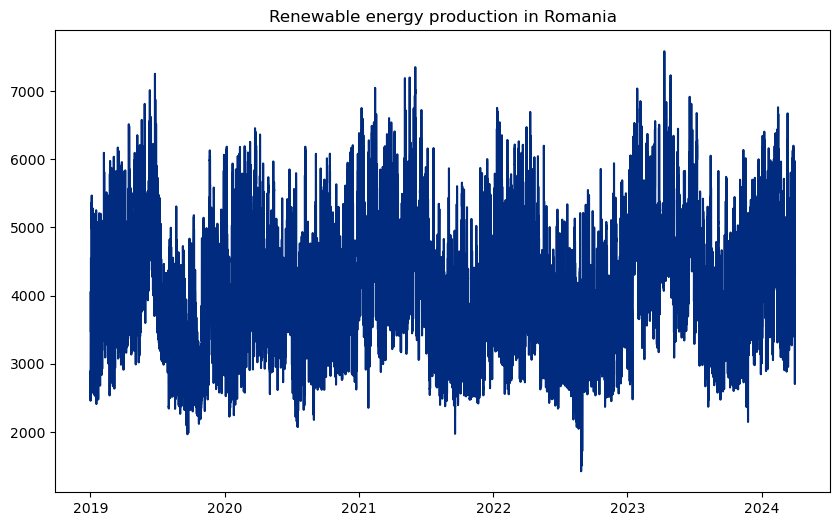

In [ ]:
#Creamos nueva columna 
df['Renewable'] = df['Production'] - df['Coal'] - df['Oil and Gas']

plt.figure(figsize=(10, 6))
plt.plot(df.DateTime, df.Renewable, color='#002B7F')
plt.title('Renewable energy production ')

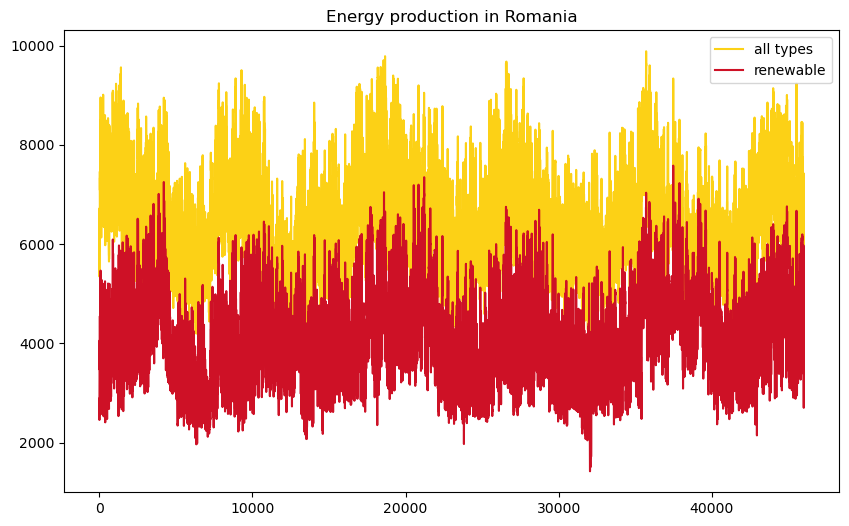

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df.Production, color='#FCD116', label='all types')
plt.plot(df.Renewable, color='#CE1126', label='renewable')
plt.legend()
plt.title('Energy production in Romania');

### Visualización de múltiples variables de datos

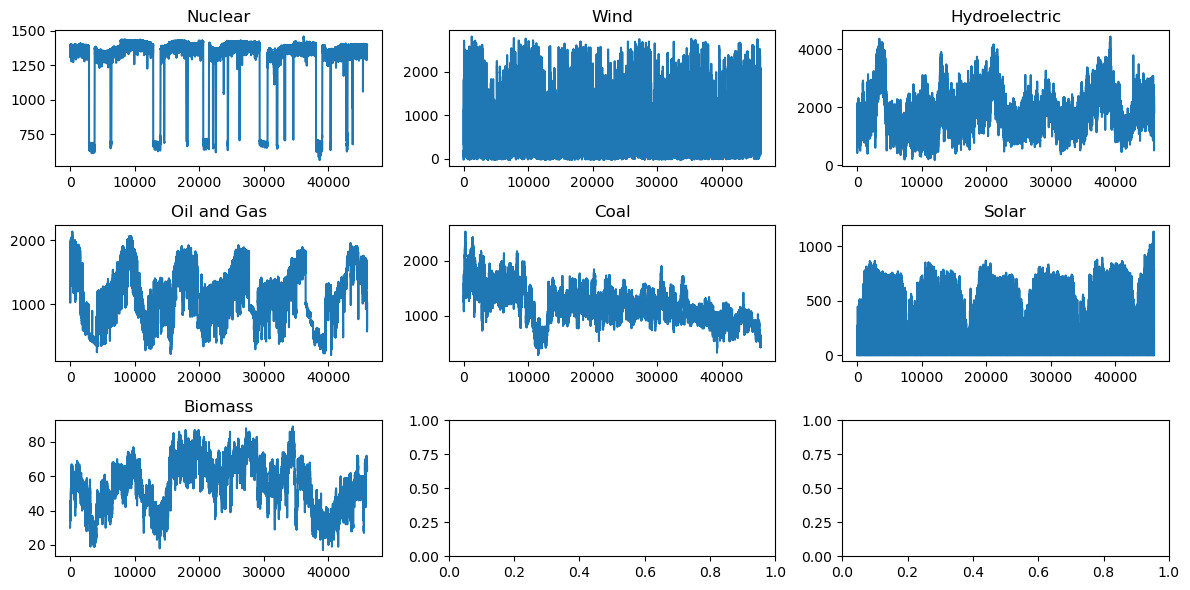

In [ ]:
_, ax = plt.subplots(3, 3, tight_layout=True, figsize=(12,6))

#Iterar sobre las columnas 3 a 9 del DataFrame y los subgráficos planos
for i, a in zip(np.arange(3, 10), ax.flat):
    a.plot(df.iloc[:, i])
    a.set_title(df.columns[i]);

# Preprocesado

In [ ]:
# Crear una nueva columna en el DataFrame que almacena el año de la columna DateTime
df['group_ids'] = df.DateTime.dt.year

In [ ]:
# Filtrar el DataFrame para excluir datos del año 2024, manteniendo solo columnas específicas
df = df.loc[df.group_ids != 2024, ['DateTime', 'group_ids', 'Renewable']]

time_idx = np.ones(2)

# Para cada valor único en group_ids (cada año), se calcula el número de filas correspondientes.
# Se concatenan rangos de índices (empezando desde 0) al arreglo time_idx para representar posiciones relativas dentro de cada año.
for i in df.group_ids.unique():  
    a = df.loc[df.group_ids == i].shape[0]  # Número de filas correspondientes al año actual
    time_idx = np.concatenate((time_idx, np.arange(a)))  # Concatenar un rango de índices para el año

# Ajustar el índice eliminando los valores iniciales de la inicialización
time_idx = time_idx[2:]

# Asignar el índice de tiempo al DataFrame como una nueva columna
df['time_idx'] = time_idx

In [9]:
#change dtypes
df['time_idx'] = df.time_idx.astype('int')
df['Renewable'] = df.Renewable.astype('float')

In [10]:
df

,DateTime,group_ids,Renewable,time_idx
0,2019-01-01 00:00:00,2019,2887.0,0
1,2019-01-01 01:00:00,2019,2631.0,1
2,2019-01-01 02:00:00,2019,2595.0,2
3,2019-01-01 03:00:00,2019,2590.0,3
4,2019-01-01 04:00:00,2019,2542.0,4
...,...,...,...,...
43823,2023-12-31 19:00:00,2023,4753.0,8755
43824,2023-12-31 20:00:00,2023,4776.0,8756
43825,2023-12-31 21:00:00,2023,4909.0,8757
43826,2023-12-31 22:00:00,2023,4187.0,8758


In [ ]:
# Definición de horizonte temporal (en horas): 3 meses
# Este valor se utiliza para definir la longitud de entrada y predicción en el modelado.
OUR_HORIZON = 24 * 30 * 3  

# Crear un conjunto de datos de series temporales
data_torch = TimeSeriesDataSet(
    data=df,                               # DataFrame de entrada con datos preprocesados
    time_idx='time_idx',                   # Columna que define el índice temporal único
    target='Renewable',                    # Variable objetivo (a predecir)
    group_ids=['group_ids'],               # Identificador de grupos para modelar series separadas (por año)
    max_encoder_length=int(OUR_HORIZON * 2),  # Longitud máxima de la ventana de entrada (dos horizontes)
    max_prediction_length=int(OUR_HORIZON),  # Longitud máxima de la ventana de predicción
    scalers='identity',                    # Normalización: 'identity' implica no escalar los valores
    time_varying_unknown_reals=['Renewable'] # Variables continuas desconocidas (en tiempo futuro) que varían
)

In [12]:
3*OUR_HORIZON

6480

In [ ]:
# Crear los conjuntos de entrenamiento y validación
train = data_torch.from_dataset(data_torch, df.iloc[:-(3*OUR_HORIZON), :])
valid = data_torch.from_dataset(data_torch, df.iloc[-(3*OUR_HORIZON):, :])

# Crear los dataloaders para entrenamiento y validación
train_dataloader = train.to_dataloader(batch_size=256, num_workers=3)
valid_dataloader = valid.to_dataloader(batch_size=256, num_workers=3)

c:\Users\alexa\anaconda3\Lib\site-packages\pytorch_forecasting\data\timeseries.py:1301: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 1 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_ids': 2023}]
  warnings.warn(


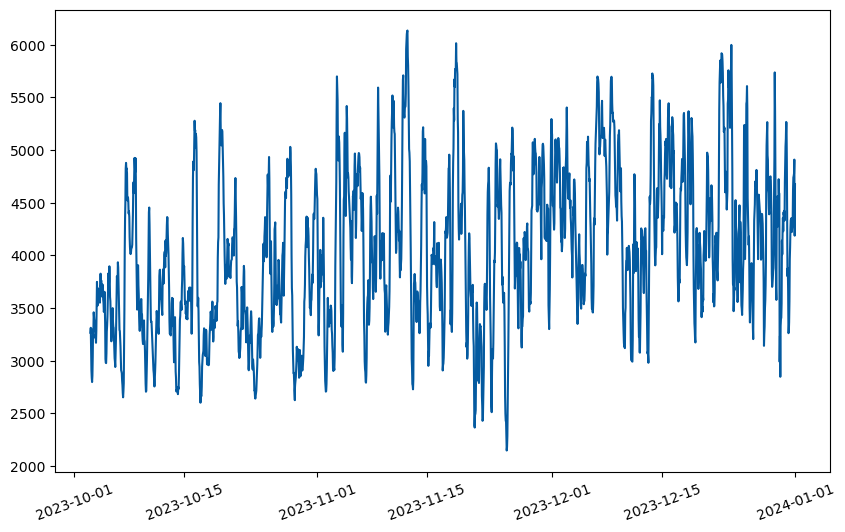

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(df.iloc[-OUR_HORIZON:, 0], df.iloc[-OUR_HORIZON:, 2], color='#045AA0')
plt.tick_params(axis='x', rotation=20)

In [ ]:
nhits = NHiTS(
    prediction_length=OUR_HORIZON,   # El horizonte de predicción, es decir, cuántos pasos hacia el futuro se predicen.
    context_length=2*OUR_HORIZON,    # El largo del contexto, cuántos pasos pasados el modelo usa para hacer predicciones.
    interpolation_mode='cubic-x',    # Modo de interpolación para manejar series temporales con diferentes frecuencias.
    n_blocks=[1, 1, 2],              # Definición de la estructura de bloques de la red (capas).
    learning_rate=2*1e-2,            # Tasa de aprendizaje
    logging_metrics=nn.ModuleList([MAE(), MASE()])   # Métricas a registrar durante el entrenamiento. Se utilizan para evaluar el rendimiento del modelo.
)

net = nhits.from_dataset(train, optimizer="Adam")


c:\Users\alexa\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\alexa\anaconda3\Lib\site-packages\lightning\pytorch\utilities\parsing.py:208: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
c:\Users\alexa\anaconda3\Lib\site-packages\pytorch_forecasting\models\nhits\__init__.py:199: UserWarning: In pytorch-forecasting models, on versions 1.1.X, the default optimizer defaults to 'adam', if pytorch_optimizer is not installed, otherwise it defaults to 'ranger' from pytorch_optimizer. From version 1.2.0, the default optimizer will be 'adam' regardless of whether pytorch_optimizer is installed, in order to minimize the number of dependencies 

In [ ]:
trainer = pl.Trainer(
    accelerator="cpu",  # Especifica el tipo de hardware utilizado para entrenar el modelo. En este caso, se usa la CPU.
    devices=1,          # Determina cuántos dispositivos (CPU o GPU) se utilizan. Aquí se utiliza un único dispositivo.
    max_epochs=200,     # Establece el número máximo de épocas (pasadas completas a través del conjunto de entrenamiento).
    log_every_n_steps=10 # Define la frecuencia de registro (logging) de métricas durante el entrenamiento, cada 10 pasos.
)

trainer.fit(
    net,                          # Modelo a entrenar.
    train_dataloaders=train_dataloader,  # DataLoader con los datos de entrenamiento.
    val_dataloaders=valid_dataloader    # DataLoader con los datos de validación para evaluar el rendimiento.
)

In [ ]:
energy_forecast = net.predict(
    valid_dataloader,                         # DataLoader que proporciona los datos de validación para realizar predicciones.
    trainer_kwargs=dict(accelerator='cpu'),   # Argumentos adicionales para el entrenador, especificando que el cálculo debe realizarse en la CPU.
    return_y=True,                            # Indica que se deben devolver las etiquetas reales (si están disponibles en el DataLoader).
    return_x=True,                            # Indica que también se deben devolver las características de entrada utilizadas para las predicciones.
    mode='raw'                                # Define el modo de predicción; "raw" indica que se devolverán las predicciones en su forma original (sin procesar).
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\alexa\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:475: Your `predict_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
c:\Users\alexa\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:419: Consider setting `persistent_workers=True` in 'predict_dataloader' to speed up the dataloader worker initialization.


In [ ]:
# Calcula el error absoluto medio (MAE) entre las predicciones del modelo y las etiquetas reales.
MAE()(energy_forecast.output.prediction, energy_forecast.y)

tensor(644.3996)

Graficos


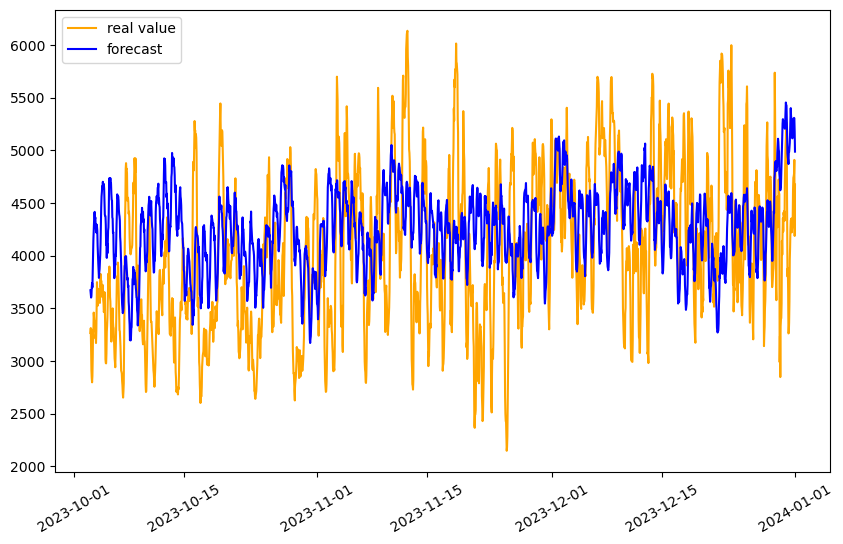

In [21]:
daterange = df.iloc[-OUR_HORIZON:, 0]
plt.figure(figsize=(10, 6))
plt.plot(daterange, energy_forecast.y[0].numpy()[0], label='real value', color='orange')
plt.plot(daterange, energy_forecast.output.prediction.numpy()[0], label='forecast',
         color='blue')
plt.tick_params(axis='x', rotation=30)
plt.legend()

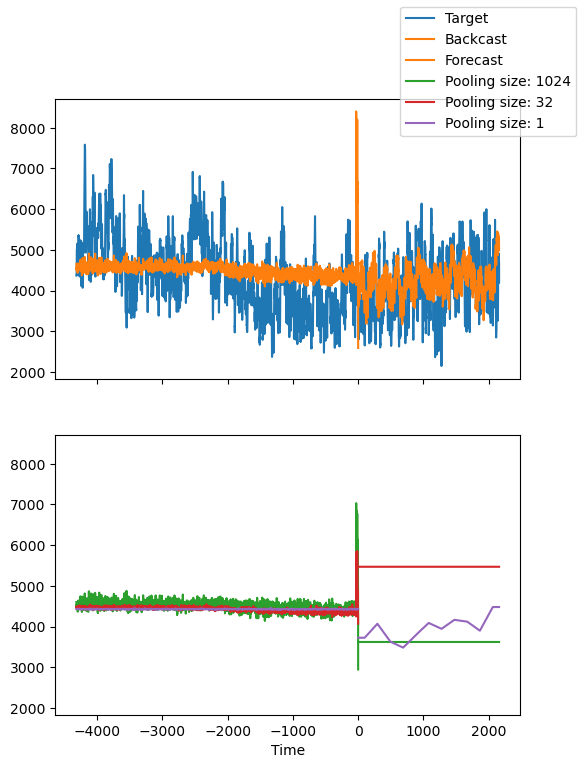

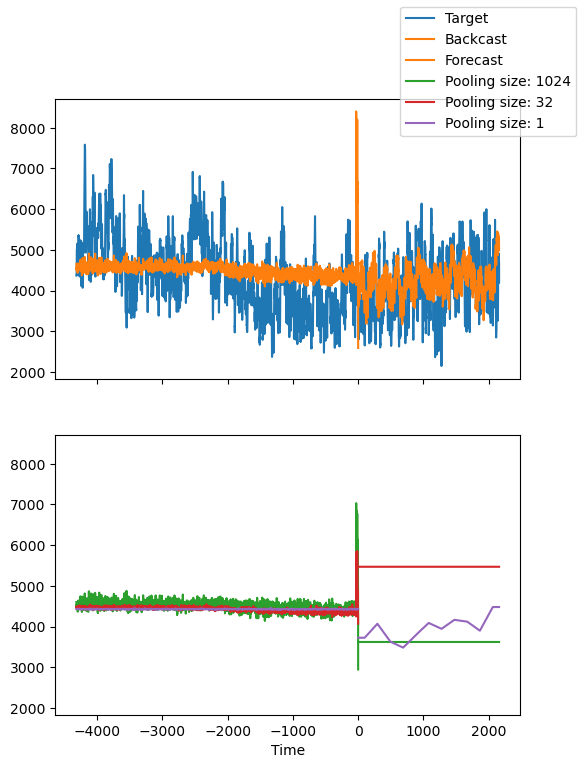

In [22]:
net.plot_interpretation(energy_forecast.x, energy_forecast.output, 0)